In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image


import torch
import main

import segmentation_models_pytorch as smp

In [2]:
mask = np.array(Image.open(
    r'.\Datasets\Electron Microscopy Image Masks\TiO2_Masks_Manual_4connected\1908248_m.tif'
))

print(mask.shape)
print(np.unique(mask))

(768, 1024)
[  0 255]


In [3]:
main.load()

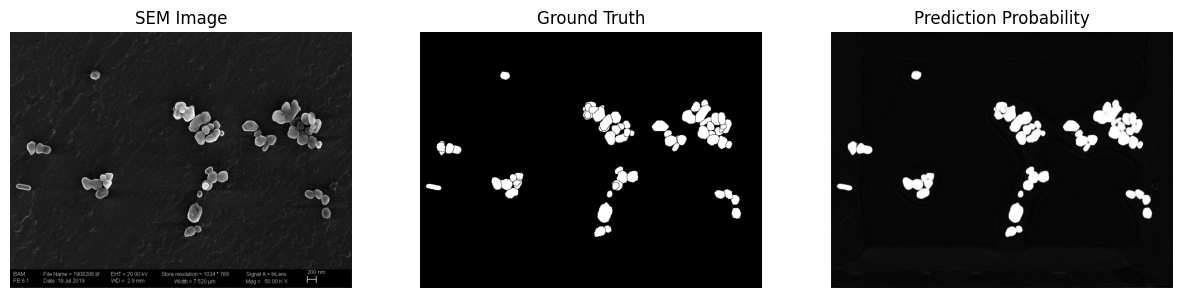

In [5]:
main.model.eval()

images, masks = next(iter(main.val_loader))

with torch.no_grad():
    preds = main.model(images.to(main.device))
    preds = torch.sigmoid(preds)

image = images[0, 0].cpu().numpy()
mask = masks[0, 0].cpu().numpy()
pred = preds[0, 0].cpu().numpy()

plt.figure(figsize=(15,5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('SEM Image')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title('Ground Truth')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(pred, cmap='gray')
plt.title('Prediction Probability')
plt.axis('off')

plt.savefig('Results_preview.pdf')
plt.show()

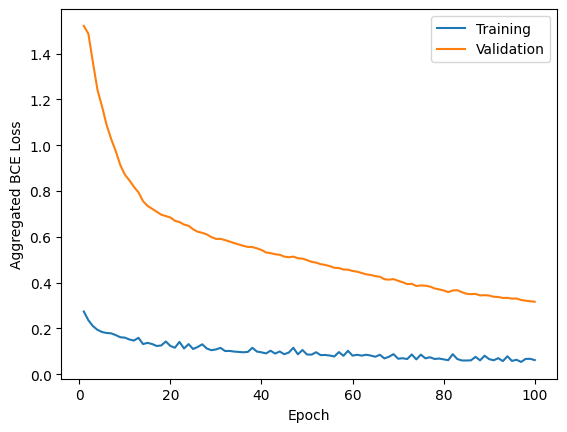

In [16]:
loss_df = pd.read_csv('loss_history.csv')
train_losses = loss_df['train_losses']
val_losses = loss_df['val_losses']
epochs = np.arange(1, len(train_losses)+1)

plt.plot(epochs, train_losses/15, label='Training')
plt.plot(epochs, val_losses, label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Aggregated BCE Loss')
plt.legend()
plt.savefig('loss_history.pdf')
plt.show()

In [26]:
def dice_score(pred, target, threshold=0.5):

    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()

    dice = (
        2 * intersection
        / (pred.sum() + target.sum() + 1e-8)
    )

    return dice

def iou_score(pred, target, threshold=0.5):

    pred = torch.sigmoid(pred)
    pred = (pred > threshold).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    iou = intersection / (union + 1e-8)

    return iou

In [24]:
def run_scores():

    main.model.eval()

    running_dice = 0
    running_iou = 0

    with torch.no_grad():

        for images, masks in main.val_loader:

            images = images.to(main.device)
            masks = masks.to(main.device)

            pred = main.model(images)

            running_dice += dice_score(pred, masks).item()
            running_iou += iou_score(pred, masks).item()

    return running_dice/ len(main.val_loader), running_iou/ len(main.val_loader)

In [27]:
print(run_scores())

(0.9568309187889099, 0.9172347187995911)
